# Exploratory Data Analysis (EDA)

In this notebook, we will explore the Appliance Energy Prediction Dataset. The main objectives are:
1. Data Loading & Understanding
2. Summary Statistics
3. Handling Missing Values
4. Distribution Analysis
5. Correlation Matrix & Time-Series Trends

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [13]:
# Load the dataset
data_path = '../data/raw/energy_data_set.csv'
try:
    df = pd.read_csv(data_path)
    # Convert simply 'date' column to datetime
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df.set_index('date', inplace=True)
    
    print(f"Dataset shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print(f"File not found at {data_path}. Please ensure the dataset is downloaded.")

Dataset shape: (19735, 28)


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


### 1. Data Understanding & Summary Statistics
Let's check the data types and basic statistics to understand the scale of our features.

In [14]:
# Check data types and for any missing values directly
print(df.info())

# Basic summary statistics
display(df.describe())

<class 'pandas.DataFrame'>
DatetimeIndex: 19735 entries, 2016-01-11 17:00:00 to 2016-05-27 18:00:00
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Appliances   19735 non-null  int64  
 1   lights       19735 non-null  int64  
 2   T1           19735 non-null  float64
 3   RH_1         19735 non-null  float64
 4   T2           19735 non-null  float64
 5   RH_2         19735 non-null  float64
 6   T3           19735 non-null  float64
 7   RH_3         19735 non-null  float64
 8   T4           19735 non-null  float64
 9   RH_4         19735 non-null  float64
 10  T5           19735 non-null  float64
 11  RH_5         19735 non-null  float64
 12  T6           19735 non-null  float64
 13  RH_6         19735 non-null  float64
 14  T7           19735 non-null  float64
 15  RH_7         19735 non-null  float64
 16  T8           19735 non-null  float64
 17  RH_8         19735 non-null  float64
 18  T9           19735 non

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


### 2. Handling Missing Values
Checking the exact count of missing values per column. In time-series, missing values are usually handled via interpolation or forward/backward filling rather than dropping rows, to maintain temporal sequence.

In [15]:
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values[missing_values > 0])

# Just in case, let's set up an interpolation method for any missing time-series points
if missing_values.sum() > 0:
    print("Interpolating missing values...")
    df = df.interpolate(method='time')
else:
    print("No missing values found.")

Missing values per column:
 Series([], dtype: int64)
No missing values found.


### 3. Distribution Analysis
Visualizing the distribution of our target variable `Appliances` (energy consumption) and `Lights`.

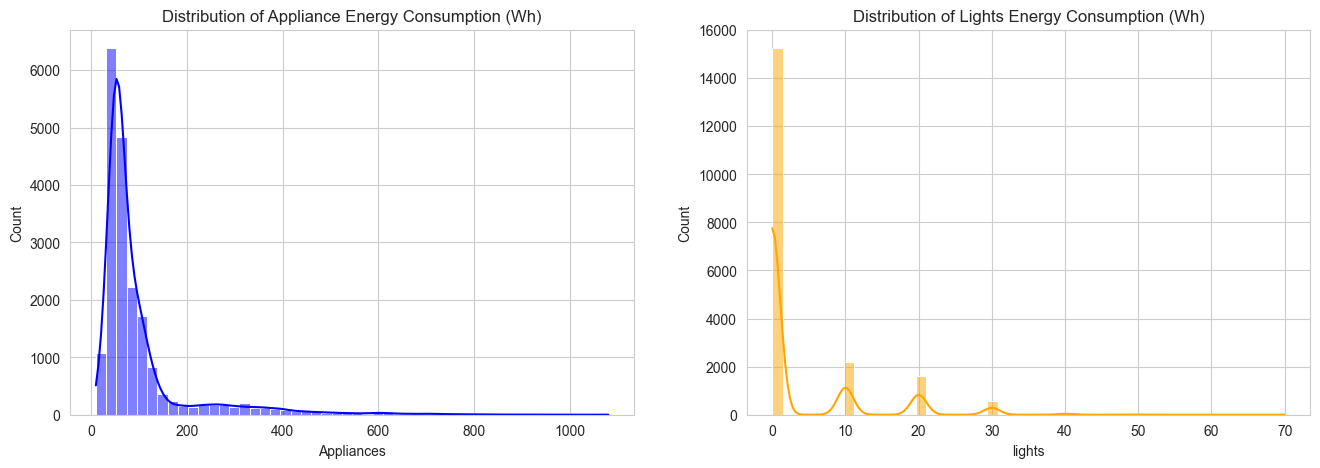

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Target Variable (Appliances)
sns.histplot(df['Appliances'], bins=50, kde=True, ax=ax[0], color='blue')
ax[0].set_title('Distribution of Appliance Energy Consumption (Wh)')

# Lights Variable
if 'lights' in df.columns:
    sns.histplot(df['lights'], bins=50, kde=True, ax=ax[1], color='orange')
    ax[1].set_title('Distribution of Lights Energy Consumption (Wh)')
else:
    print("Column 'lights' not found, skipping its plot.")

plt.show()

### 4. Correlation Matrix
Checking for multicollinearity among the temperature and humidity sensors, and how they correlate with the target variable `Appliances`.

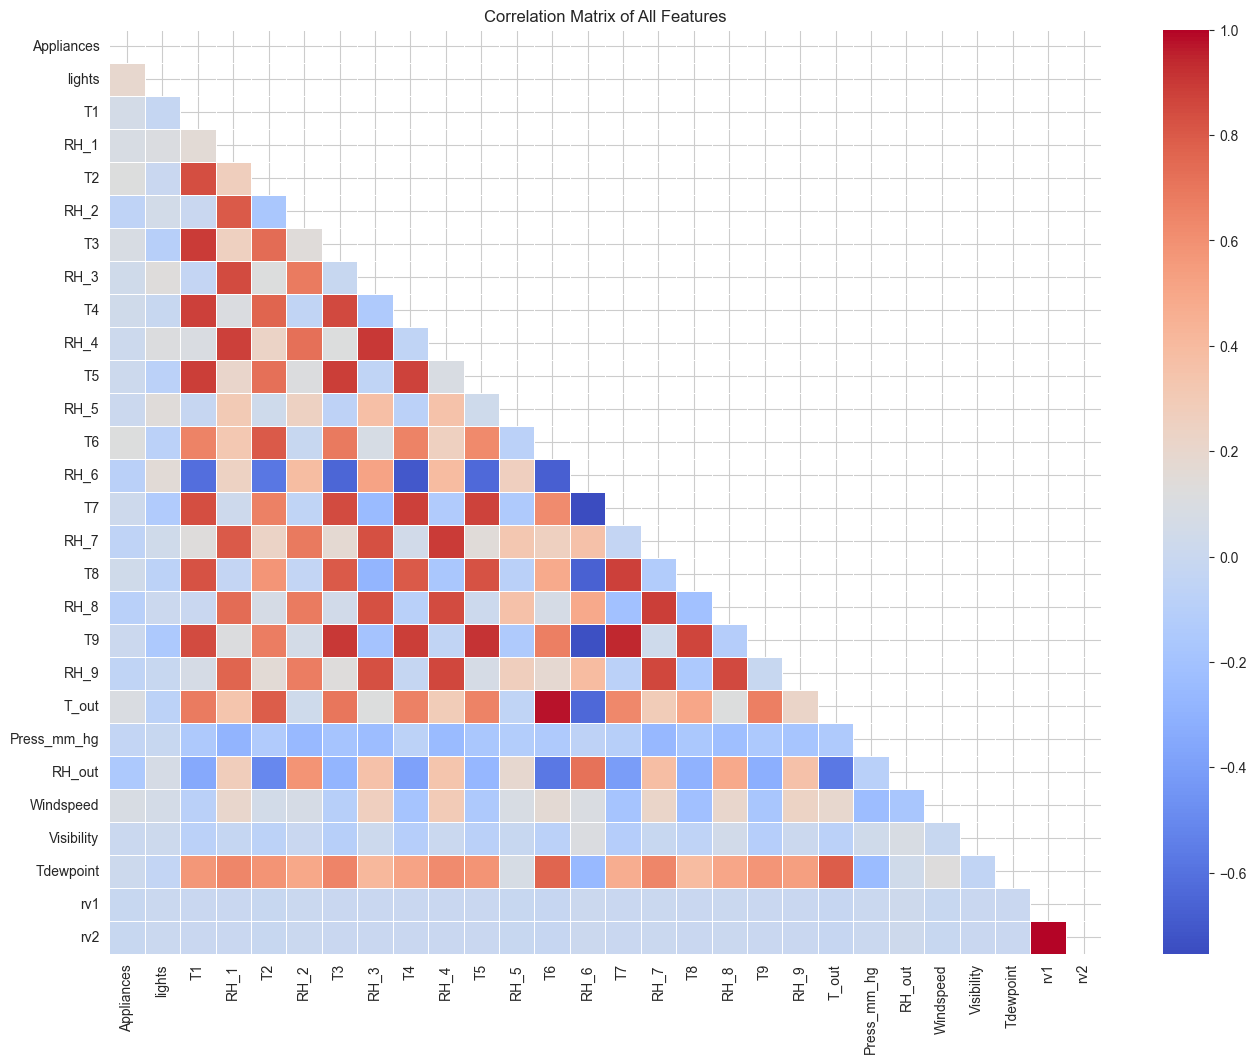

Top correlations with Appliances:
Appliances    1.000000
lights        0.197278
T2            0.120073
T6            0.117638
T_out         0.099155
Windspeed     0.087122
RH_1          0.086031
T3            0.085060
T1            0.055447
T4            0.040281
Name: Appliances, dtype: float64

Bottom correlations with Appliances:
RH_out        -0.152282
RH_8          -0.094039
RH_6          -0.083178
RH_2          -0.060465
RH_7          -0.055642
RH_9          -0.051462
Press_mm_hg   -0.034885
rv1           -0.011145
rv2           -0.011145
Visibility     0.000230
Name: Appliances, dtype: float64


In [ ]:
plt.figure(figsize=(16, 12))
# Only correlate numeric columns
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Mask the upper triangle for easier readability
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of All Features')
plt.xticks(fontsize=12)
plt.show()

# Let's see the top variables correlated with Appliances
print("Top correlations with Appliances:")
print(corr_matrix['Appliances'].sort_values(ascending=False).head(10))
print("\nBottom correlations with Appliances:")
print(corr_matrix['Appliances'].sort_values(ascending=True).head(10))